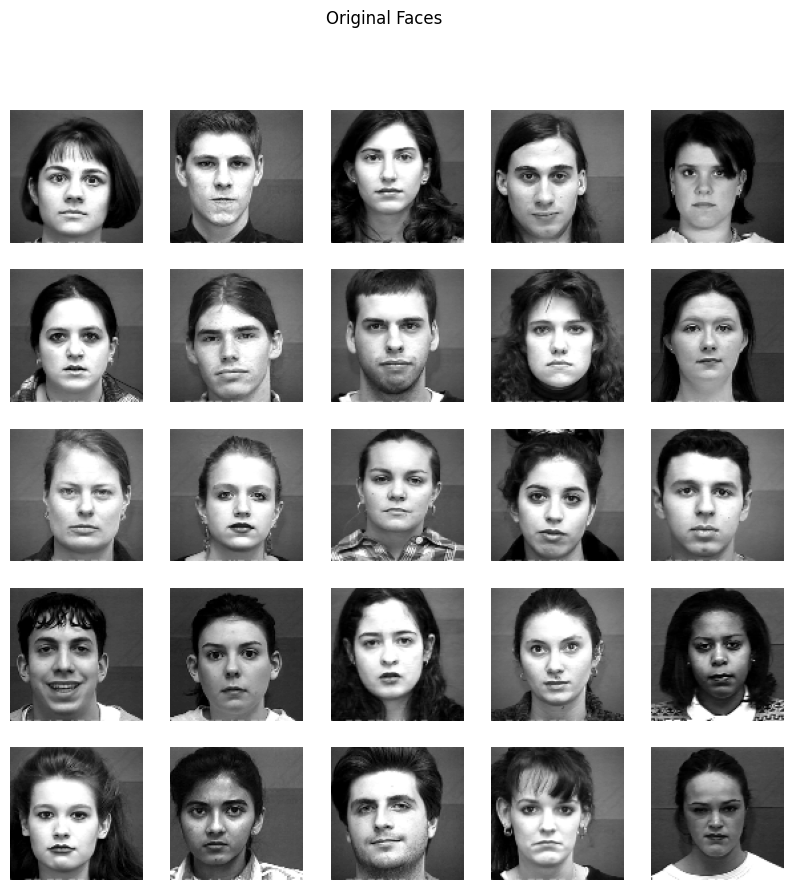

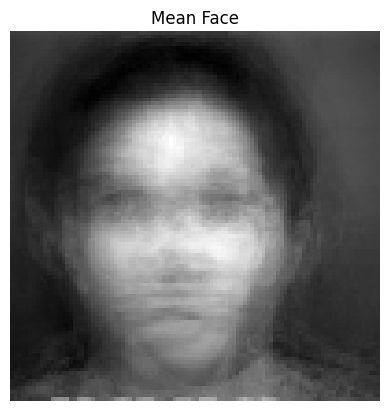

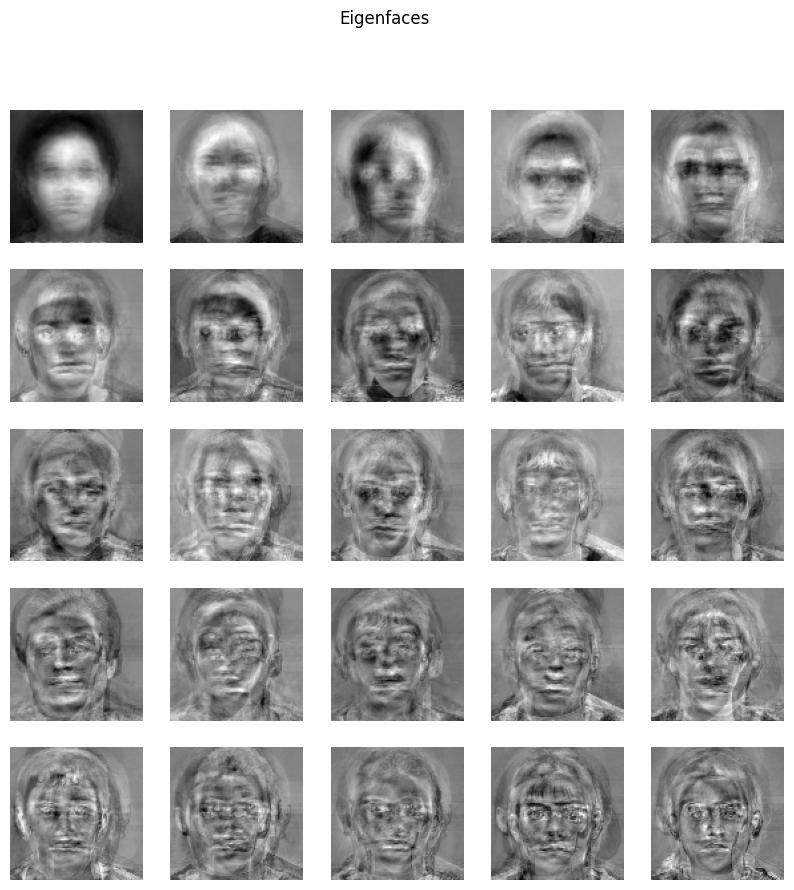

In [1]:
#Task1
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

train_img = "./Eigenfaces/Train"
image_f = os.listdir(train_img)
images = []
target_size = (100, 100)

for file in image_f:
    image_p = os.path.join(train_img, file)
    image = cv2.imread(image_p, cv2.IMREAD_GRAYSCALE)
    if image is not None:
        resized = cv2.resize(image, target_size)
        images.append(resized)
        
plt.figure(figsize=(10, 10))
for i in range(len(images)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.axis('off')
plt.suptitle('Original Faces')
plt.show()

images_np = np.array(images)
mean_f = np.mean(images_np, axis=0)
n = images_np.shape[0]
avg = np.mean(images_np, axis=(1, 2)).reshape(-1, 1, 1)
centered_vectors = images_np - avg
centered_reshape = centered_vectors.reshape(n, -1)
covariance_matrix = np.dot(centered_reshape.T, centered_reshape)

values, vectors = np.linalg.eig(covariance_matrix)
values = np.diag(values)
values, indices = np.sort(np.diag(values), axis=0)[::-1], np.argsort(np.diag(values), axis=0)[::-1]
eigevectors = vectors[:, indices]

plt.figure()
plt.imshow(mean_f, cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show()

n_eigenfaces = (vectors.real - np.min(vectors.real)) / (np.max(vectors.real) - np.min(vectors.real)) * 255

plt.figure(figsize=(10, 10))
for i in range(25):
    eigenface = n_eigenfaces[:, i].reshape(mean_f.shape)
    plt.subplot(5, 5, i + 1)
    plt.imshow(eigenface, cmap='gray')
    plt.axis('off')
plt.suptitle('Eigenfaces')
plt.show()


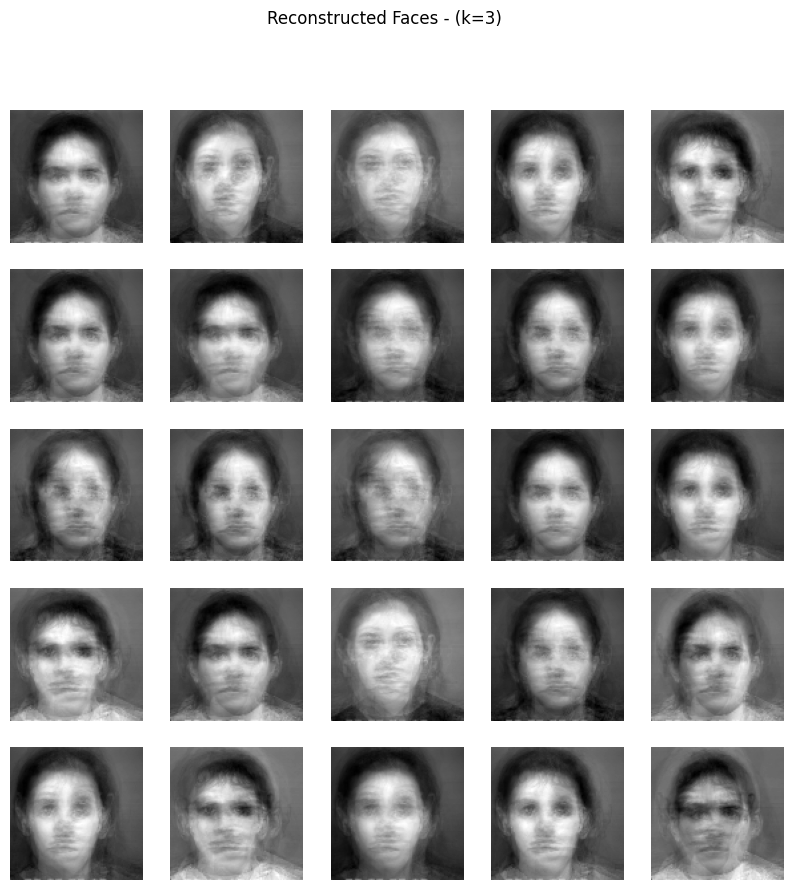

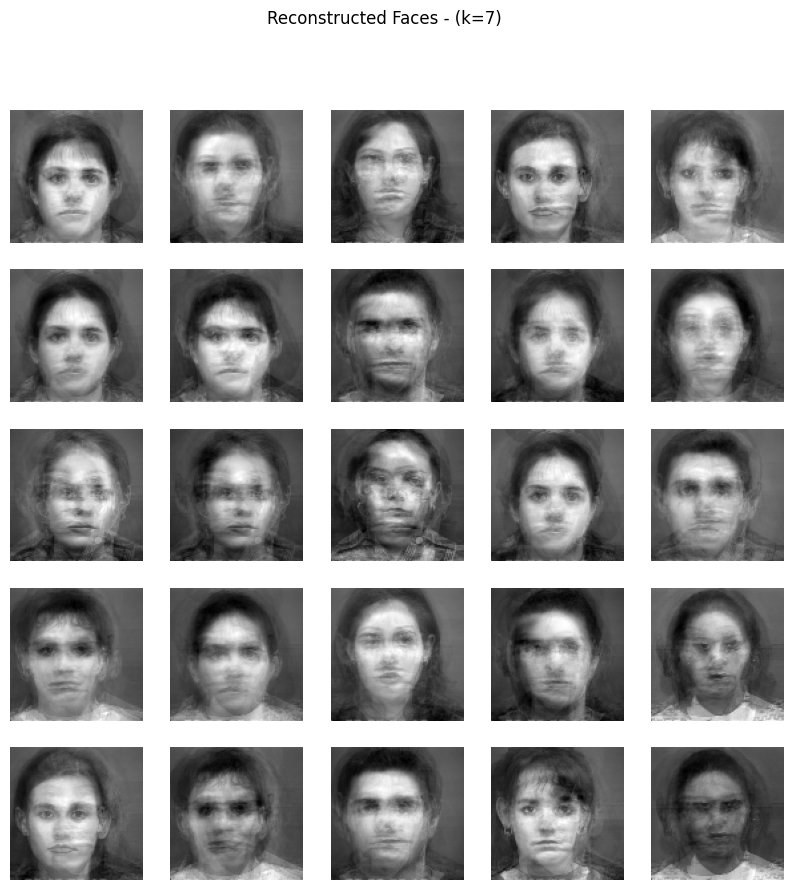

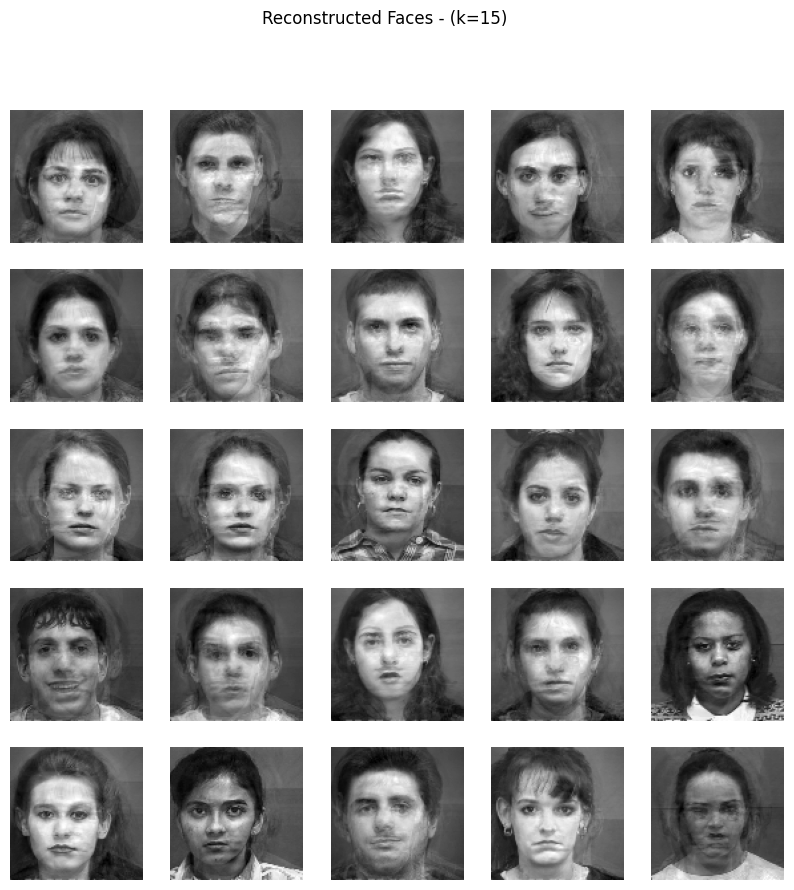

In [3]:
# Task2
k_values = [3, 7, 15]
for k in k_values:
    selected = n_eigenfaces[:, :k]  
    weights = np.dot(centered_reshape, selected)
    reconstructed_faces = mean_f.reshape(1, *target_size) + np.dot(weights, selected.T).reshape(-1, *target_size)
    
    plt.figure(figsize=(10, 10))
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(reconstructed_faces[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Reconstructed Faces - (k={k})')
    plt.show()


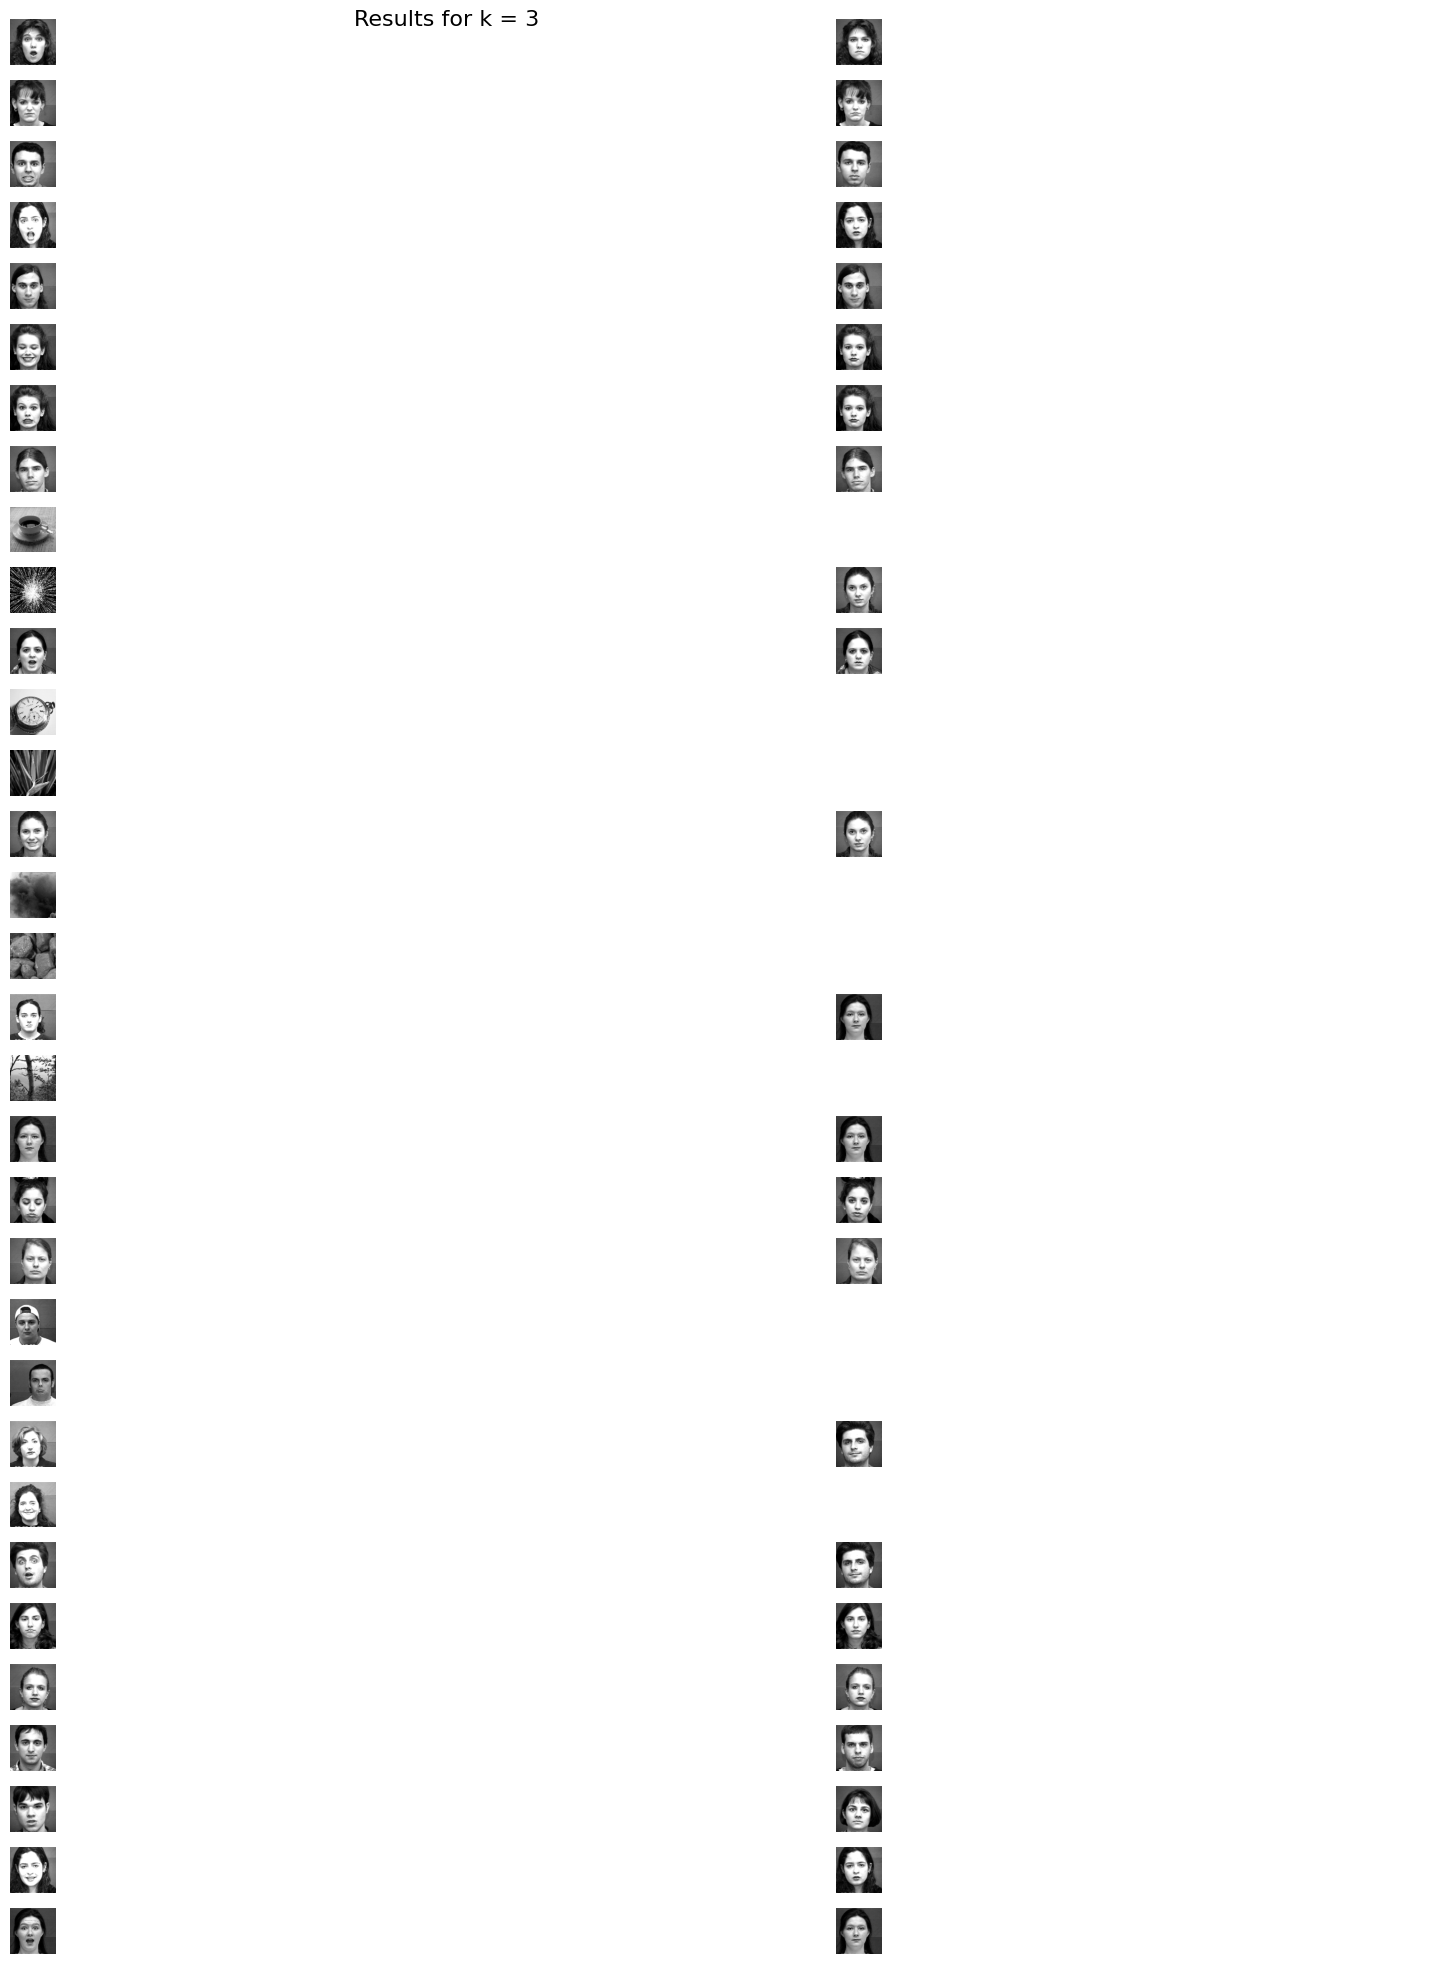

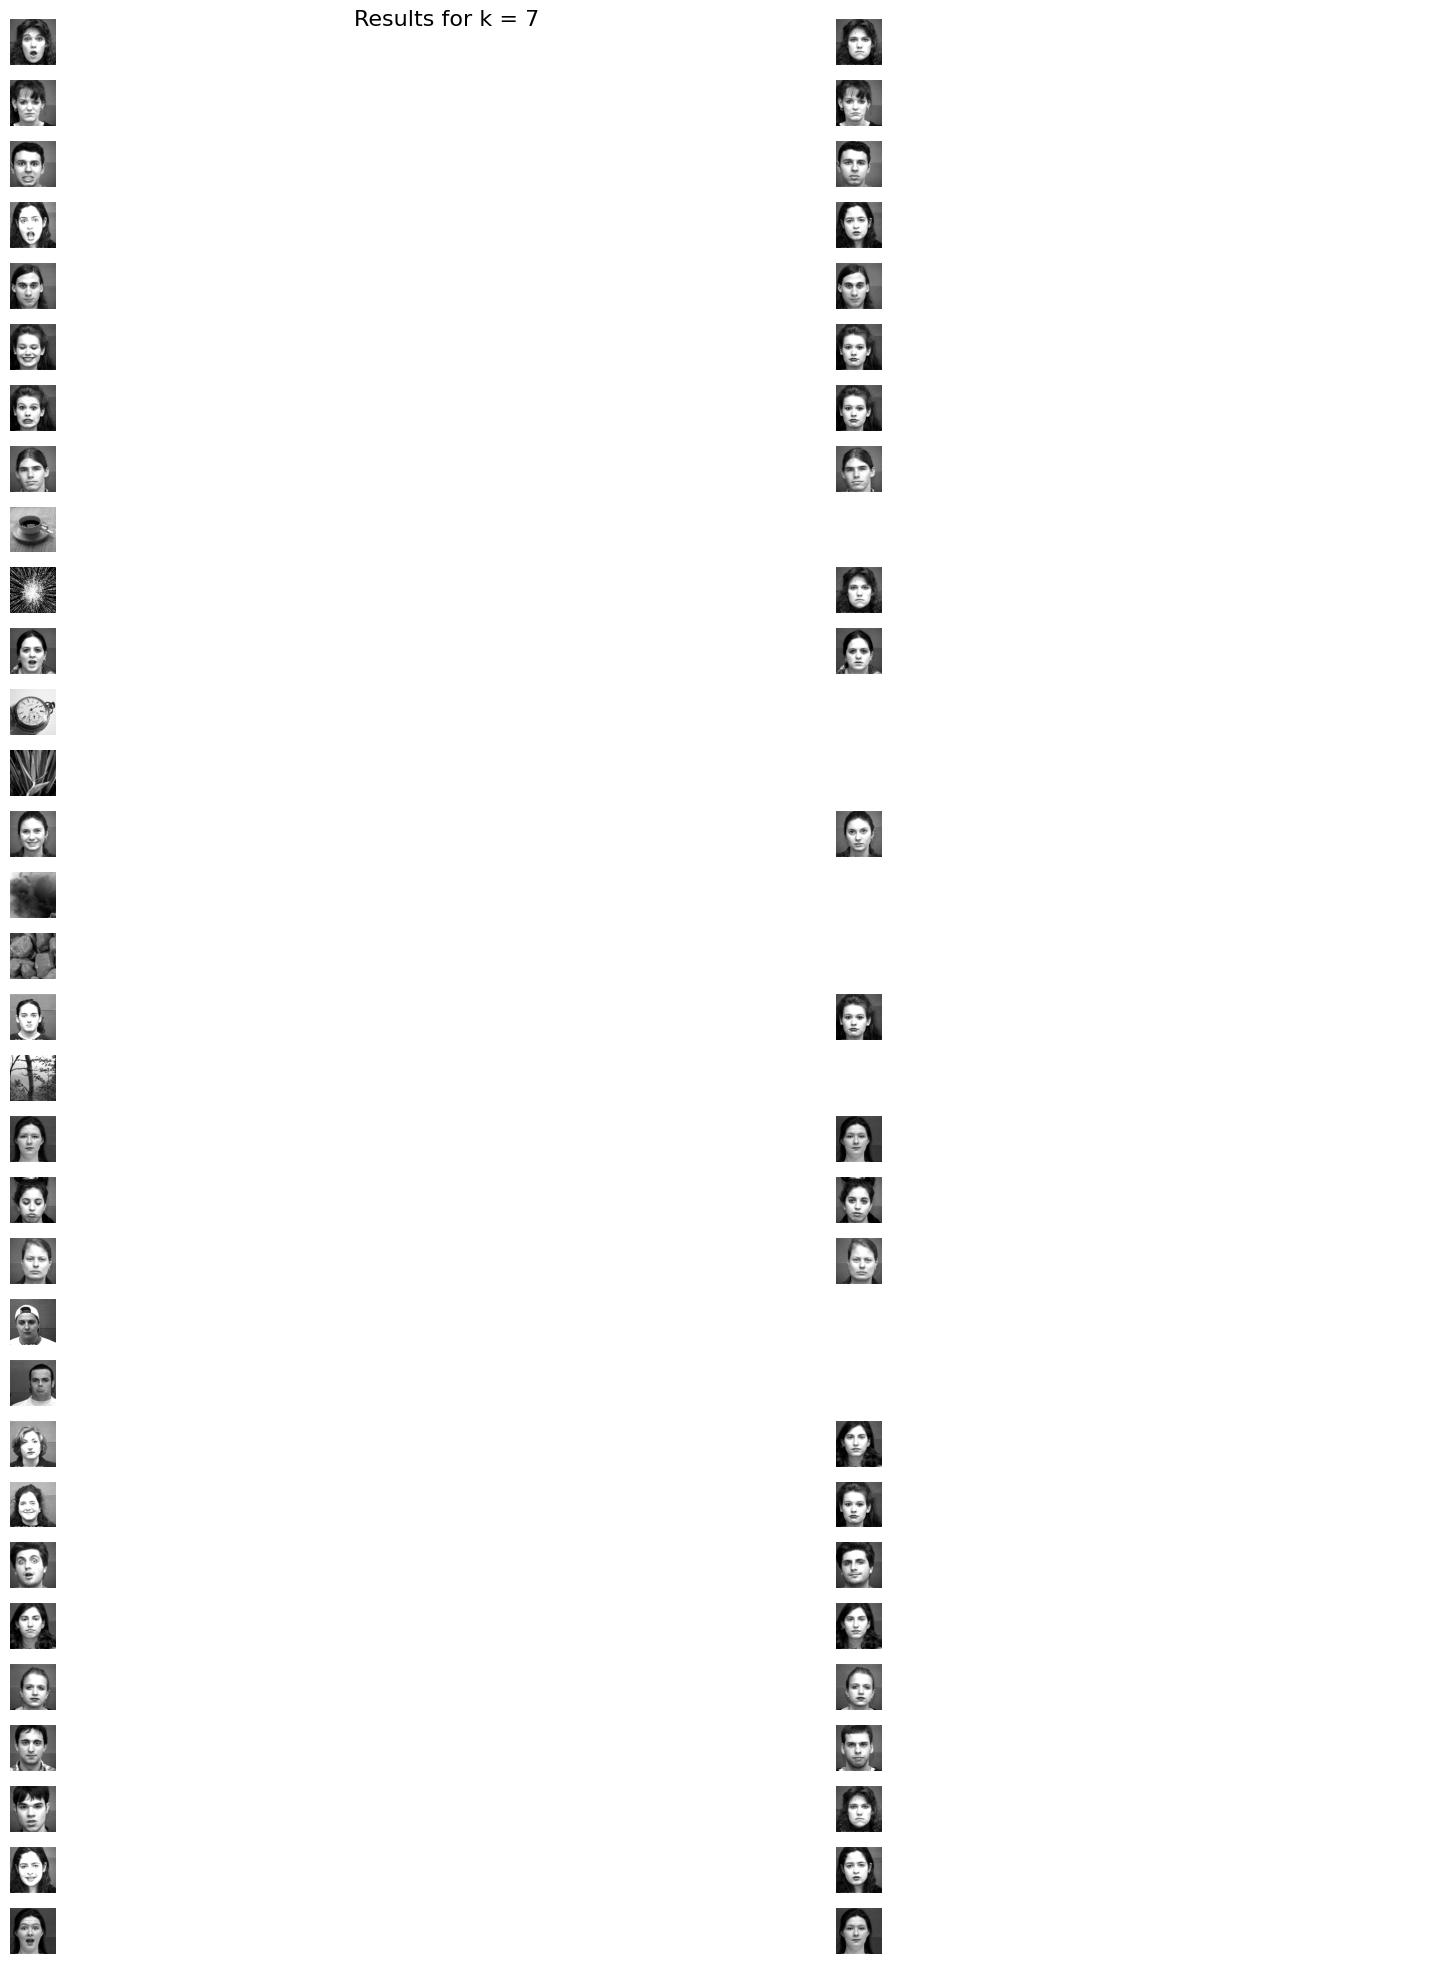

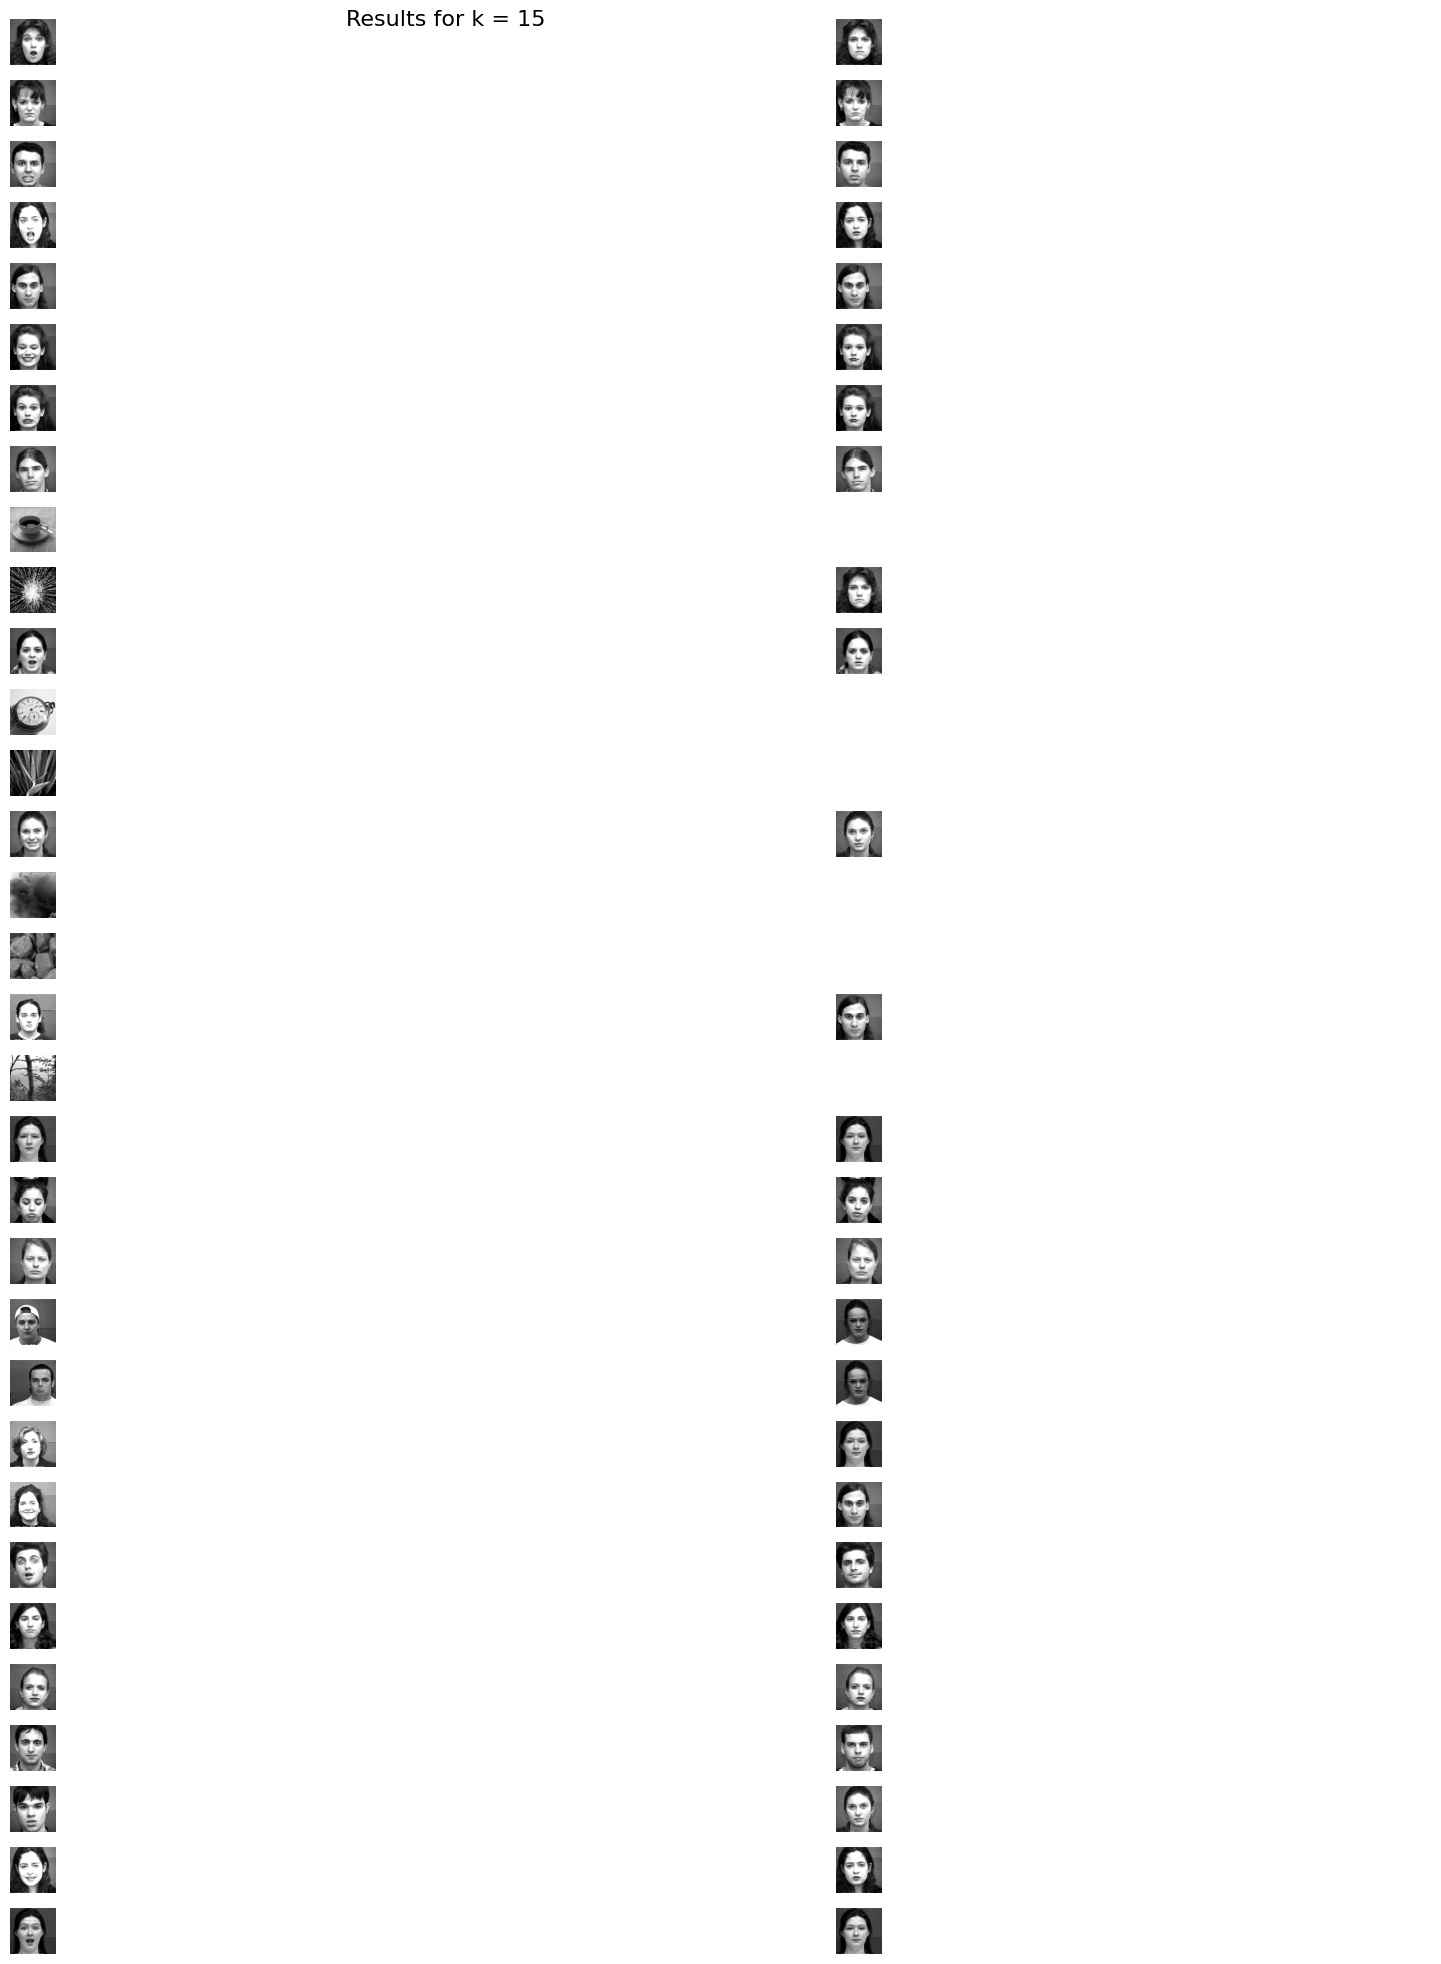

In [1]:
#Task-3
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def input_images(folder):
    f_images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, filename), cv2.IMREAD_GRAYSCALE) 
        if img is not None:
            resized = cv2.resize(img, (100, 100))  
            n_img = (resized - np.mean(resized)) / np.std(resized) 
            f_images.append(n_img.flatten())  
    return f_images

def calculate_eigenfaces(images, k):
    pca = PCA(n_components=k)
    pca.fit(images)
    eigenfaces = pca.components_
    mean_image = pca.mean_
    return eigenfaces, None, mean_image

def classify_images(test_images, training_images, eigenfaces, mean_image, threshold):
    classified_images = []
    for test_img in test_images:
        test_fimg = test_img.flatten()
        test_pimg = np.dot(test_fimg - mean_image, eigenfaces.T)
        reconstructed_img = mean_image + np.dot(test_pimg, eigenfaces)
        error = np.linalg.norm(test_fimg - reconstructed_img)
        if error < threshold:
            distances = [np.linalg.norm(test_pimg - np.dot((train_img.flatten() - mean_image), eigenfaces.T)) for train_img in training_images]
            c_index = np.argmin(distances)
            c_image = training_images[c_index]
            classified_images.append((test_img, c_image))
        else:
            classified_images.append((test_img, None))  
    return classified_images


def display_results(results, k):
    fig, axs = plt.subplots(len(results), 2, figsize=(20, 20))  
    for i, pair in enumerate(results):
        test_img, closest_img = pair
        axs[i, 0].imshow(test_img.reshape(100, 100), cmap='gray')  
        axs[i, 0].axis('off')
        if closest_img is not None:
            axs[i, 1].imshow(closest_img.reshape(100, 100), cmap='gray')  
        axs[i, 1].axis('off')
    plt.suptitle(f"Results for k = {k}", fontsize=16)
    plt.tight_layout()
    plt.show()
 
test_folder = "./Eigenfaces/Test"
test_images = input_images(test_folder)

training_folder = "./Eigenfaces/Train"
training_images = input_images(training_folder)

k_values = [3, 7, 15]
threshold = 92

for k in k_values:
    eigenfaces, _, mean_image = calculate_eigenfaces(training_images, k)  
    classified_results = classify_images(test_images, training_images, eigenfaces, mean_image, threshold)
    display_results(classified_results, k)


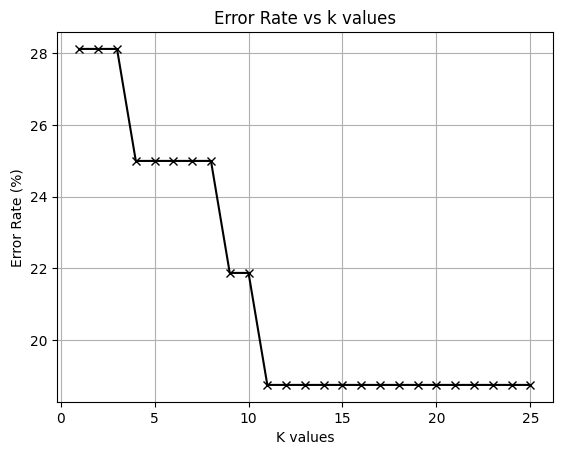

In [2]:
#Task-4
def error(test_results):
    total_images = len(test_results)
    misclassified_images = sum(1 for pair in test_results if pair[1] is None)
    error_rate = (misclassified_images / total_images) * 100
    return error_rate

def plot_error (k_values, error_rates):
    plt.plot(k_values, error_rates, marker='x', color='black')
    plt.title('Error Rate vs k values')
    plt.xlabel('K values')
    plt.ylabel('Error Rate (%)')
    plt.grid(True)
    plt.show()

k_values = range(1, 26)
error_rates = []
for k in k_values:
    eigenfaces, _, mean_image = calculate_eigenfaces(training_images, k)
    classified_results = classify_images(test_images, training_images, eigenfaces, mean_image, threshold)
    error_rate = error(classified_results)
    error_rates.append(error_rate)
plot_error(k_values, error_rates)
